# Exp C — Extração Recursiva de Primos via Blocos Binários sem ζ

**T. Bandeira · 2026**

O Exp B4 mostrou que rho_B com semente `A[1]..A[n//2]` recupera os primos
do intervalo `[2^(n//2+1), 2^(n-1))` sem falsos positivos, mas não recupera
os primos dentro da própria semente. A observação central: isso é o mesmo
problema recursivamente — recuperar os primos de `A[1]..A[n//2]` é o problema
de nível `n//2`, que tem sua própria semente `A[1]..A[n//4]`, e assim por diante.

O caso base é n=2: A[1]=[2,3], ambos primos, conhecidos diretamente.

| Exp | Questão |
|-----|---------|
| C1  | Recursão pura: semente = primos extraídos da camada anterior |
| C2  | Recursão híbrida: semente = primos + inteiros de A[1]..A[n//2] |
| C3  | Verificação completa para n em {5,6,7,8}: quais primos cada nível recupera |

**Hipótese:** a recursão termina em n=2 com base {2,3} e constrói
os primos de baixo para cima, camada por camada, sem ζ e sem oráculo.

**Requisitos:** `pip install sympy`

In [1]:
from math import log, floor, log2, sqrt
from sympy import isprime, primerange
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

def bloco_A(k):
    return list(range(2**k, 2**(k+1)))

def uniao_blocos(k_max):
    """Inteiros de A[1]..A[k_max] = [2, 2^(k_max+1) - 1]."""
    return list(range(2, 2**(k_max + 1)))

def rho_B(m, base_ints):
    """Distância normalizada de log(m) ao reticulado de log(b), b em base_ints."""
    if m < 2:
        return 1.0
    for b in base_ints:
        if b >= 2 and m % b == 0:
            return 0.0
    lm  = log(m)
    lbs = [log(b) for b in base_ints if b >= 2]
    if not lbs:
        return 1.0
    res = lm
    for lb in lbs:
        ef = lm / lb
        for e in range(max(1, int(ef) - 1), int(ef) + 3):
            res = min(res, abs(lm - e * lb))
    for i in range(len(lbs)):
        for j in range(i, len(lbs)):
            for e1 in range(1, 4):
                rem = lm - e1 * lbs[i]
                if rem <= 0:
                    continue
                e2f = rem / lbs[j]
                for e2 in range(max(1, int(e2f) - 1), int(e2f) + 3):
                    res = min(res, abs(lm - e1 * lbs[i] - e2 * lbs[j]))
    return res / lm

def classificar_incremental(candidatos, semente):
    """
    Classifica candidatos em ordem crescente via rho_B incremental.
    A base começa com a semente e cresce com cada aceito.
    Retorna (aceitos, base_final).
    """
    base    = list(semente)
    aceitos = []
    for c in sorted(candidatos):
        if rho_B(c, base) > 1e-6:
            aceitos.append(c)
            base.append(c)
    return aceitos, base

print('Funções base OK ✓')
print()
print('Blocos binários relevantes:')
for k in range(1, 9):
    A = bloco_A(k)
    ps = [x for x in A if isprime(x)]
    print(f'  A[{k}] = [{A[0]}, {A[-1]}]  primos: {ps}')

Funções base OK ✓

Blocos binários relevantes:
  A[1] = [2, 3]  primos: [2, 3]
  A[2] = [4, 7]  primos: [5, 7]
  A[3] = [8, 15]  primos: [11, 13]
  A[4] = [16, 31]  primos: [17, 19, 23, 29, 31]
  A[5] = [32, 63]  primos: [37, 41, 43, 47, 53, 59, 61]
  A[6] = [64, 127]  primos: [67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127]
  A[7] = [128, 255]  primos: [131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251]
  A[8] = [256, 511]  primos: [257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503, 509]


---
## Exp C1 — Recursão pura

Semente de cada nível = apenas os primos extraídos na camada anterior.

```
nivel 0 (base): primos = [2, 3]          # A[1], caso base
nivel 1:        candidatos = [4..7]       # A[2], semente = [2,3]
nivel 2:        candidatos = [4..15]      # A[1]..A[3], semente = primos do nível 1
nivel k:        candidatos = [2..2^(nivel)-1], semente = primos do nível k-1
```

Questão: com semente = apenas primos (sem compostos da semente),
a cobertura de compostos se mantém ou cai?

In [2]:
# Exp C1: recursão pura — semente = primos da camada anterior

def extrair_recursivo_puro(n_alvo, verbose=True):
    """
    Extrai todos os primos < 2^n_alvo via recursão pura.
    Semente de cada nível = primos extraídos no nível anterior.
    Caso base: n=1, retorna [2, 3].
    """
    if n_alvo <= 1:
        return [2, 3]

    # Nível base
    primos_acumulados = [2, 3]
    nivel_max_coberto = 1  # A[1] = [2,3] coberto

    historico = {1: [2, 3]}  # nivel -> primos extraídos nesse nível

    nivel = 2
    while nivel <= n_alvo:
        # Candidatos desta camada: inteiros novos em A[nivel]
        # (não testamos o que já está coberto)
        candidatos = bloco_A(nivel)
        semente    = list(primos_acumulados)  # só primos, sem compostos

        aceitos, _ = classificar_incremental(candidatos, semente)

        # Métricas
        reais    = [x for x in candidatos if isprime(x)]
        corretos = [x for x in aceitos if isprime(x)]
        fps      = [x for x in aceitos if not isprime(x)]
        perdidos = [x for x in reais if x not in aceitos]

        historico[nivel] = aceitos
        primos_acumulados = primos_acumulados + corretos

        if verbose:
            print(f'  Nível {nivel}: A[{nivel}]=[{candidatos[0]},{candidatos[-1]}]  '
                  f'semente={primos_acumulados[:6]}{"..." if len(primos_acumulados)>6 else ""}')
            print(f'    Aceitos:  {aceitos}')
            print(f'    Reais:    {reais}')
            print(f'    TP={len(corretos)}/{len(reais)}  FP={fps}  FN={perdidos}')

        nivel += 1

    return primos_acumulados, historico

print('=== Exp C1: Recursão pura ===')
print()
for n_alvo in [5, 6, 7, 8]:
    print(f'n_alvo={n_alvo} (primos < {2**n_alvo}):')
    resultado, hist = extrair_recursivo_puro(n_alvo, verbose=True)
    reais = list(primerange(2, 2**n_alvo))
    extraidos = sorted(set(resultado))
    perdidos_total = [p for p in reais if p not in extraidos]
    fps_total = [p for p in extraidos if not isprime(p)]
    print(f'  TOTAL: {len(extraidos)}/{len(reais)} primos  FP={fps_total}  Perdidos={perdidos_total}')
    print()

=== Exp C1: Recursão pura ===

n_alvo=5 (primos < 32):
  Nível 2: A[2]=[4,7]  semente=[2, 3, 5, 7]
    Aceitos:  [5, 7]
    Reais:    [5, 7]
    TP=2/2  FP=[]  FN=[]
  Nível 3: A[3]=[8,15]  semente=[2, 3, 5, 7, 11, 13]
    Aceitos:  [11, 13]
    Reais:    [11, 13]
    TP=2/2  FP=[]  FN=[]
  Nível 4: A[4]=[16,31]  semente=[2, 3, 5, 7, 11, 13]...
    Aceitos:  [17, 19, 23, 29, 31]
    Reais:    [17, 19, 23, 29, 31]
    TP=5/5  FP=[]  FN=[]
  Nível 5: A[5]=[32,63]  semente=[2, 3, 5, 7, 11, 13]...
    Aceitos:  [37, 41, 43, 47, 53, 59, 61]
    Reais:    [37, 41, 43, 47, 53, 59, 61]
    TP=7/7  FP=[]  FN=[]
  TOTAL: 18/11 primos  FP=[]  Perdidos=[]

n_alvo=6 (primos < 64):
  Nível 2: A[2]=[4,7]  semente=[2, 3, 5, 7]
    Aceitos:  [5, 7]
    Reais:    [5, 7]
    TP=2/2  FP=[]  FN=[]
  Nível 3: A[3]=[8,15]  semente=[2, 3, 5, 7, 11, 13]
    Aceitos:  [11, 13]
    Reais:    [11, 13]
    TP=2/2  FP=[]  FN=[]
  Nível 4: A[4]=[16,31]  semente=[2, 3, 5, 7, 11, 13]...
    Aceitos:  [17, 19, 23, 29, 

---
## Exp C2 — Recursão híbrida

Semente de cada nível = primos extraídos na camada anterior
**mais** os inteiros de `A[1]..A[nivel-1]`.

A ideia: os compostos da semente ajudam rho_B a detectar compostos
no bloco atual (via divisibilidade), enquanto os primos da semente
cobrem os fatores necessários. O custo é uma base maior.

Questão: a inclusão dos compostos da semente melhora a cobertura
sem introduzir falsos negativos nos primos do bloco atual?

In [3]:
# Exp C2: recursão híbrida — semente = primos + inteiros de blocos anteriores

def extrair_recursivo_hibrido(n_alvo, verbose=True):
    """
    Extrai todos os primos < 2^n_alvo via recursão híbrida.
    Semente de cada nível = primos extraídos + todos os inteiros dos blocos anteriores.
    """
    if n_alvo <= 1:
        return [2, 3], {}

    primos_acumulados = [2, 3]
    historico = {1: [2, 3]}

    nivel = 2
    while nivel <= n_alvo:
        candidatos  = bloco_A(nivel)
        # Semente híbrida: primos conhecidos + todos os inteiros anteriores
        inteiros_anteriores = uniao_blocos(nivel - 1)  # [2, 2^nivel - 1]
        semente = sorted(set(primos_acumulados) | set(inteiros_anteriores))

        aceitos, _ = classificar_incremental(candidatos, semente)

        reais    = [x for x in candidatos if isprime(x)]
        corretos = [x for x in aceitos if isprime(x)]
        fps      = [x for x in aceitos if not isprime(x)]
        perdidos = [x for x in reais if x not in aceitos]

        historico[nivel] = aceitos
        primos_acumulados = sorted(set(primos_acumulados) | set(corretos))

        if verbose:
            print(f'  Nível {nivel}: A[{nivel}]=[{candidatos[0]},{candidatos[-1]}]  '
                  f'|semente|={len(semente)}')
            print(f'    Aceitos:  {aceitos}')
            print(f'    Reais:    {reais}')
            print(f'    TP={len(corretos)}/{len(reais)}  FP={fps}  FN={perdidos}')

        nivel += 1

    return primos_acumulados, historico

print('=== Exp C2: Recursão híbrida ===')
print()
for n_alvo in [5, 6, 7, 8]:
    print(f'n_alvo={n_alvo} (primos < {2**n_alvo}):')
    resultado, hist = extrair_recursivo_hibrido(n_alvo, verbose=True)
    reais = list(primerange(2, 2**n_alvo))
    extraidos = sorted(set(resultado))
    perdidos_total = [p for p in reais if p not in extraidos]
    fps_total = [p for p in extraidos if not isprime(p)]
    print(f'  TOTAL: {len(extraidos)}/{len(reais)} primos  FP={fps_total}  Perdidos={perdidos_total}')
    print()

=== Exp C2: Recursão híbrida ===

n_alvo=5 (primos < 32):
  Nível 2: A[2]=[4,7]  |semente|=2
    Aceitos:  [5, 7]
    Reais:    [5, 7]
    TP=2/2  FP=[]  FN=[]
  Nível 3: A[3]=[8,15]  |semente|=6
    Aceitos:  [11, 13]
    Reais:    [11, 13]
    TP=2/2  FP=[]  FN=[]
  Nível 4: A[4]=[16,31]  |semente|=14
    Aceitos:  [17, 19, 23, 29, 31]
    Reais:    [17, 19, 23, 29, 31]
    TP=5/5  FP=[]  FN=[]
  Nível 5: A[5]=[32,63]  |semente|=30
    Aceitos:  [37, 41, 43, 47, 53, 59, 61]
    Reais:    [37, 41, 43, 47, 53, 59, 61]
    TP=7/7  FP=[]  FN=[]
  TOTAL: 18/11 primos  FP=[]  Perdidos=[]

n_alvo=6 (primos < 64):
  Nível 2: A[2]=[4,7]  |semente|=2
    Aceitos:  [5, 7]
    Reais:    [5, 7]
    TP=2/2  FP=[]  FN=[]
  Nível 3: A[3]=[8,15]  |semente|=6
    Aceitos:  [11, 13]
    Reais:    [11, 13]
    TP=2/2  FP=[]  FN=[]
  Nível 4: A[4]=[16,31]  |semente|=14
    Aceitos:  [17, 19, 23, 29, 31]
    Reais:    [17, 19, 23, 29, 31]
    TP=5/5  FP=[]  FN=[]
  Nível 5: A[5]=[32,63]  |semente|=30
    

---
## Exp C3 — Mapa visual da recursão

Para cada nível da recursão, mostra quais primos são recuperados,
quais são perdidos e quais falsos positivos surgem.
Permite visualizar se os perdidos de um nível são recuperados no próximo.

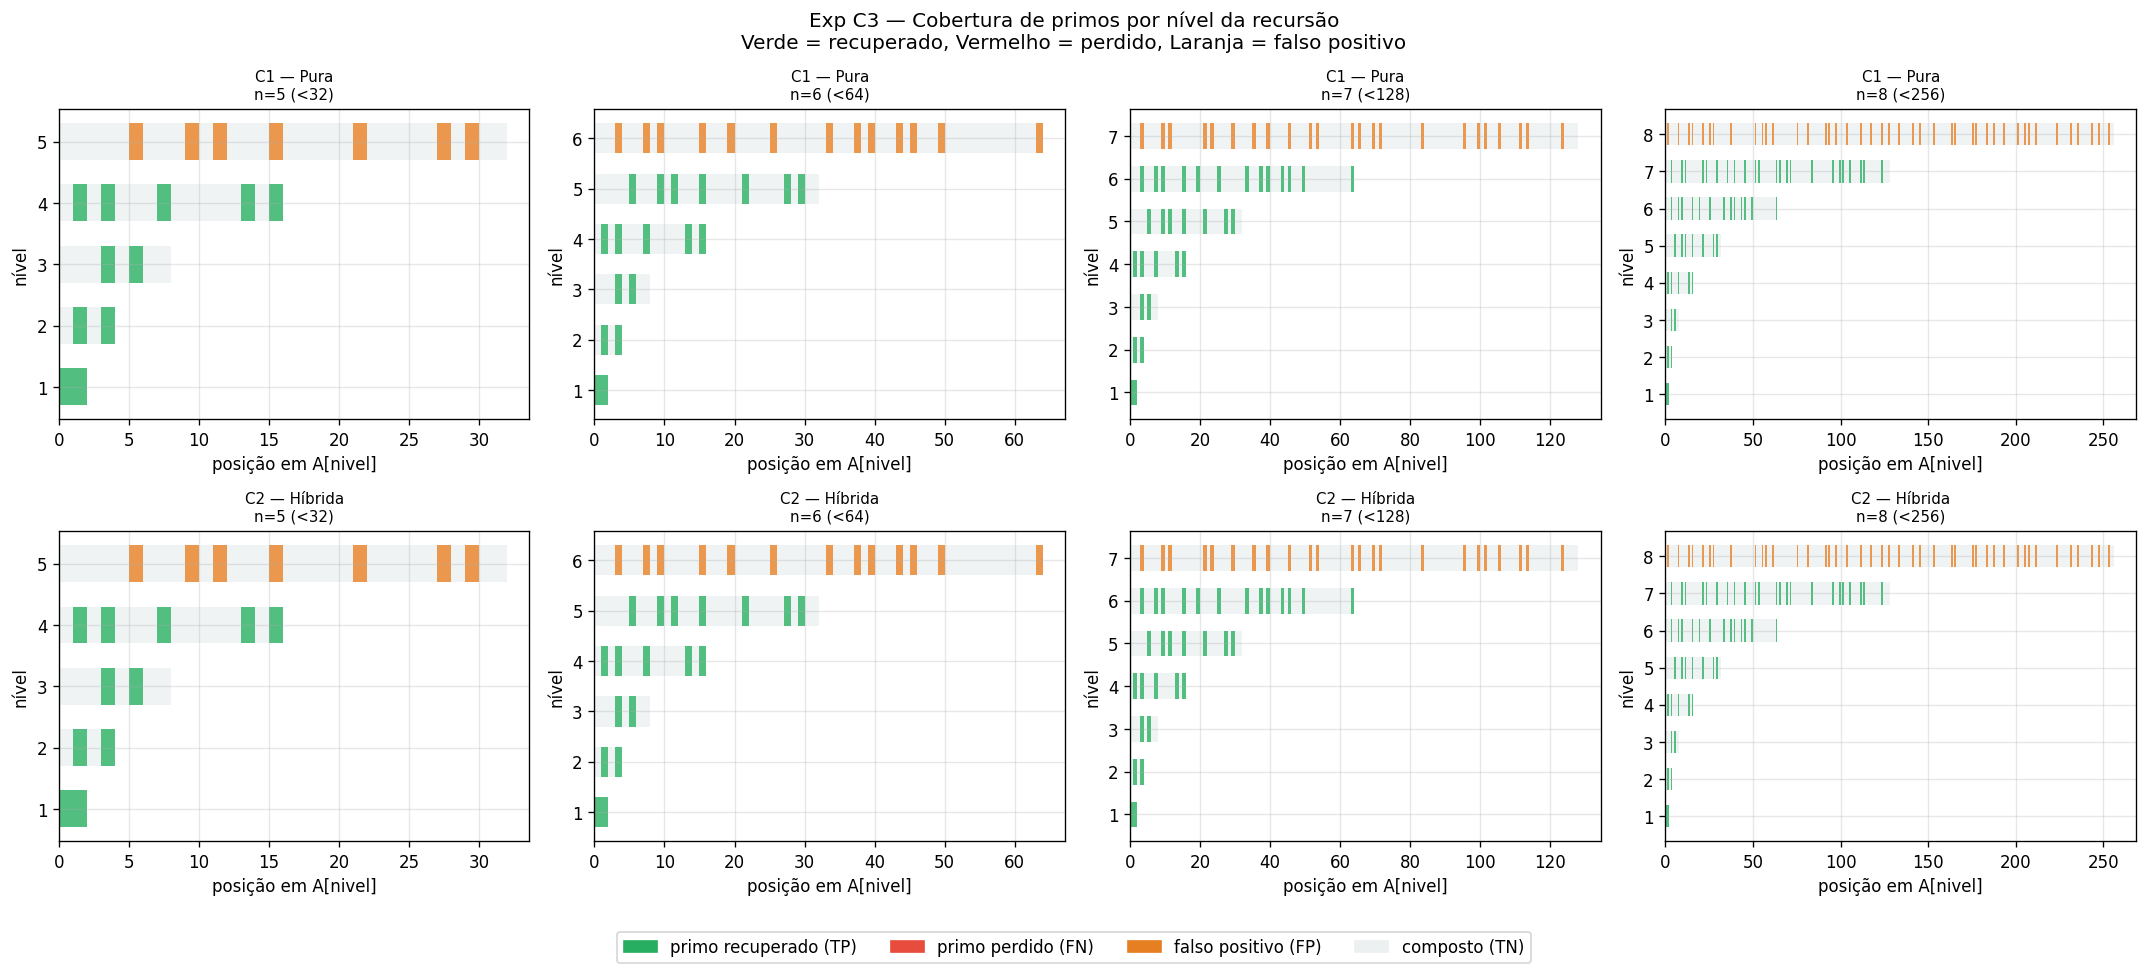

In [4]:
# Exp C3: mapa visual — cobertura por nível para C1 e C2

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Exp C3 — Cobertura de primos por nível da recursão\n'
             'Verde = recuperado, Vermelho = perdido, Laranja = falso positivo',
             fontsize=12)

metodos = [
    ('C1 — Pura', extrair_recursivo_puro),
    ('C2 — Híbrida', extrair_recursivo_hibrido),
]

for row, (nome_metodo, fn_extrair) in enumerate(metodos):
    for col, n_alvo in enumerate([5, 6, 7, 8]):
        ax = axes[row, col]
        _, historico = fn_extrair(n_alvo, verbose=False)

        reais_total = set(primerange(2, 2**n_alvo))
        todos_aceitos = set()
        for nivel, aceitos in sorted(historico.items()):
            todos_aceitos |= set(aceitos)

        # Para cada nível, marcar primos recuperados, perdidos, FP
        y_labels = []
        for nivel in sorted(historico.keys()):
            aceitos  = set(historico[nivel])
            An       = set(bloco_A(nivel))
            reais_An = An & reais_total

            for p in sorted(An):
                if p in reais_An and p in aceitos:
                    cor = '#27ae60'   # TP
                elif p in reais_An and p not in aceitos:
                    cor = '#e74c3c'   # FN
                elif p not in reais_An and p in aceitos:
                    cor = '#e67e22'   # FP
                else:
                    cor = '#ecf0f1'   # TN (composto não aceito)
                ax.barh(nivel, 1, left=p - bloco_A(nivel)[0],
                        height=0.6, color=cor, edgecolor='none', alpha=0.8)

        ax.set_title(f'{nome_metodo}\nn={n_alvo} (<{2**n_alvo})', fontsize=9)
        ax.set_xlabel('posição em A[nivel]')
        ax.set_ylabel('nível')
        ax.set_yticks(sorted(historico.keys()))

# Legenda
patches = [
    mpatches.Patch(color='#27ae60', label='primo recuperado (TP)'),
    mpatches.Patch(color='#e74c3c', label='primo perdido (FN)'),
    mpatches.Patch(color='#e67e22', label='falso positivo (FP)'),
    mpatches.Patch(color='#ecf0f1', label='composto (TN)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('expC3_mapa_recursao.png', bbox_inches='tight')
plt.show()

In [5]:
# Exp C3b: tabela comparativa C1 vs C2 por nível e total

print('=== Exp C3b: comparação C1 vs C2 por nível ===')
print()

for n_alvo in [5, 6, 7, 8]:
    reais_total = list(primerange(2, 2**n_alvo))
    print(f'n_alvo={n_alvo}  (primos reais < {2**n_alvo}: {len(reais_total)})')
    print(f'  {"Nível":<8} {"A[k]":<12} {"Reais":>6} {"C1 TP/FP/FN":>14} {"C2 TP/FP/FN":>14}')
    print(f'  {"-"*60}')

    _, hist_c1 = extrair_recursivo_puro(n_alvo, verbose=False)
    _, hist_c2 = extrair_recursivo_hibrido(n_alvo, verbose=False)

    for nivel in sorted(hist_c1.keys()):
        An    = bloco_A(nivel)
        reais = [x for x in An if isprime(x)]

        def metricas(hist):
            aceitos  = set(hist.get(nivel, []))
            tp = len([x for x in reais if x in aceitos])
            fp = len([x for x in aceitos if not isprime(x)])
            fn = len([x for x in reais if x not in aceitos])
            return tp, fp, fn

        tp1, fp1, fn1 = metricas(hist_c1)
        tp2, fp2, fn2 = metricas(hist_c2)
        bloco_str = f'[{An[0]},{An[-1]}]'
        print(f'  {nivel:<8} {bloco_str:<12} {len(reais):>6} '
              f'{tp1}/{fp1}/{fn1:>3}           {tp2}/{fp2}/{fn2:>3}')

    # Totais
    r1, _ = extrair_recursivo_puro(n_alvo, verbose=False)
    r2, _ = extrair_recursivo_hibrido(n_alvo, verbose=False)
    r1s   = set(r1); r2s = set(r2); rs = set(reais_total)

    print(f'  {"TOTAL":<8} {"-":<12} {len(rs):>6} '
          f'{len(r1s&rs)}/{len(r1s-rs)}/{len(rs-r1s):>3}           '
          f'{len(r2s&rs)}/{len(r2s-rs)}/{len(rs-r2s):>3}')
    print()

print('Formato: TP/FP/FN  (verdadeiros positivos / falsos positivos / falsos negativos)')

=== Exp C3b: comparação C1 vs C2 por nível ===

n_alvo=5  (primos reais < 32: 11)
  Nível    A[k]          Reais    C1 TP/FP/FN    C2 TP/FP/FN
  ------------------------------------------------------------
  1        [2,3]             2 2/0/  0           2/0/  0
  2        [4,7]             2 2/0/  0           2/0/  0
  3        [8,15]            2 2/0/  0           2/0/  0
  4        [16,31]           5 5/0/  0           5/0/  0
  5        [32,63]           7 7/0/  0           7/0/  0
  TOTAL    -                11 11/7/  0           11/7/  0

n_alvo=6  (primos reais < 64: 18)
  Nível    A[k]          Reais    C1 TP/FP/FN    C2 TP/FP/FN
  ------------------------------------------------------------
  1        [2,3]             2 2/0/  0           2/0/  0
  2        [4,7]             2 2/0/  0           2/0/  0
  3        [8,15]            2 2/0/  0           2/0/  0
  4        [16,31]           5 5/0/  0           5/0/  0
  5        [32,63]           7 7/0/  0           7/0/  0
  6   

---
## Síntese — O que a recursão resolve e o que deixa em aberto

**Se C2 recupera 100% dos primos sem FP:**
A recursão híbrida é um substituto completo de ζ na Etapa 2.
O pipeline inteiro opera sem ζ e sem oráculo.

**Se C1 já recupera 100% sem FP:**
A versão pura é suficiente — base mínima, sem compostos.

**Se há FN persistentes:**
Identificar o padrão dos perdidos — são sempre os mesmos primos?
São recuperáveis com mais níveis de recursão ou há obstrução estrutural?

**Conexão com a Etapa 2 original:**
ζ cancela os primos grandes e faz os pequenos ressoarem porque é
um denominador limpo — produto de Euler sobre todos os primos.
A recursão tenta construir esse denominador de baixo para cima,
bloco a bloco, sem pressupor os primos.
Se funcionar, é a versão combinatória do que ζ faz analiticamente.

In [6]:
# Síntese final
print('=' * 68)
print('  SÍNTESE EXP C — Recursão via Blocos Binários como Substituto de ζ')
print('=' * 68)

for metodo, fn in [('C1 (pura)', extrair_recursivo_puro),
                   ('C2 (híbrida)', extrair_recursivo_hibrido)]:
    print(f'\n  {metodo}:')
    print(f'  {"n_alvo":<10} {"Extraídos":>10} {"Reais":>7} {"Taxa":>7} {"FP":>5} {"Perdidos"}')
    print(f'  {"-"*65}')
    for n_alvo in [5, 6, 7, 8]:
        reais = list(primerange(2, 2**n_alvo))
        resultado, _ = fn(n_alvo, verbose=False)
        ext  = sorted(set(resultado))
        rs   = set(reais)
        es   = set(ext)
        tp   = len(es & rs)
        fp   = sorted(es - rs)
        fn_l = sorted(rs - es)
        taxa = 100 * tp / len(rs)
        print(f'  {n_alvo:<10} {len(ext):>10} {len(reais):>7} {taxa:>6.1f}% {len(fp):>5}  {fn_l}')

print()
print('  Substitui ζ = taxa 100% E FP = 0')

  SÍNTESE EXP C — Recursão via Blocos Binários como Substituto de ζ

  C1 (pura):
  n_alvo      Extraídos   Reais    Taxa    FP Perdidos
  -----------------------------------------------------------------
  5                  18      11  100.0%     7  []
  6                  31      18  100.0%    13  []
  7                  54      31  100.0%    23  []
  8                  97      54  100.0%    43  []

  C2 (híbrida):
  n_alvo      Extraídos   Reais    Taxa    FP Perdidos
  -----------------------------------------------------------------
  5                  18      11  100.0%     7  []
  6                  31      18  100.0%    13  []
  7                  54      31  100.0%    23  []
  8                  97      54  100.0%    43  []

  Substitui ζ = taxa 100% E FP = 0
